In [5]:
from llmism import InterpretiveStructuralModeling, Approach
from openai import AsyncOpenAI
import matplotlib.pyplot as plt
import networkx as nx
import httpx

In [18]:
OPENAI_URL = "TODO"
OPENAI_API_KEY = "TODO"
client = AsyncOpenAI(
    base_url=OPENAI_URL,
    api_key=OPENAI_API_KEY,
    http_client=httpx.AsyncClient(verify=False)
)

In [7]:
model = "gpt-5.2"
embedding_model = "text-embedding-3-large"
ism = InterpretiveStructuralModeling(client, model, embedding_model, Approach.FULL, responses_api_supported=False)

In [8]:
key_factors = [
    "National Mental-Health Workforce Shortage",
    "Noncompetitive Compensation",
    "Private-Sector Employer Competition",
    "Lengthy Federal Hiring Process",
    "Credentialing and Onboarding Delays",
    "Limited Qualified Applicant Pool",
    "Rural and Geographic Recruitment Challenges",
    "High Clinical Workload",
    "Excessive Caseloads",
    "Clinician Burnout",
    "Administrative Burden",
    "Excessive Documentation Requirements",
    "Productivity and Performance Pressures",
    "Insufficient Administrative Support",
    "Staffing-Induced Workload Spirals",
    "Leadership Trust and Organizational Climate",
    "Limited Career Advancement Opportunities",
    "Employee Retention and Turnover",
    "Retirement and Aging Workforce",
    "Telework and Remote-Work Flexibility",
    "Scheduling Flexibility",
    "Recruitment and Relocation Incentives",
    "Education Debt-Reduction / Loan-Repayment Incentives",
    "Psychology Internship and Fellowship Pipelines",
    "Counselor and MFT Training Pipelines",
    "Scope-of-Practice / Occupational-Mix Flexibility",
    "HR Capacity and Recruitment Support",
    "Community-Care / Private-Sector Outsourcing",
    "Funding and Position-Authorization Constraints",
    "Rising Veteran Mental-Health Service Demand",
]

In [9]:
research_question = "What are the key enablers and barriers influencing the persistent shortage of psychotherapists at the VA?"

In [10]:
x = [ """The VA plays a central role in training U.S. health professionals but faces serious mental health staffing shortages caused by national workforce gaps, inefficient hiring, turnover, heavy workloads, and bureaucratic stress. 
Although incentive programs, expanded provider roles, peer advocates, and evidence-based training help address these challenges, eligibility and implementation vary. 
Veterans generally view VA providers positively, valuing both clinical expertise and strong interpersonal relationships. 
However, high caseloads can weaken provider–patient interactions. Access is further limited by inadequate facilities, parking shortages, aging buildings, poor awareness of available services, and rural disparities. 
Rural veterans are less likely to receive mental health care and, when treated, are more likely to receive medication than psychotherapy.""",
      """Rural veterans face substantial barriers to mental health care, including long travel distances, limited transportation, fewer specialized providers, inadequate referral options, and services unavailable at nearby VA facilities. 
      Although roughly one-third of VA-enrolled veterans live in rural areas, they generally use mental health services less often despite having greater physical and mental health needs.
* Rural veterans with mental health conditions were 70% less likely to receive any mental health treatment, 52% less likely to receive outpatient treatment, and 64% less likely to receive medication than urban veterans.
* Veterans with PTSD in rural and highly rural areas had 19% and 25% fewer outpatient visits, respectively; disparities were greater for specialized PTSD care.
* Psychotherapy use increased from 2007 to 2010, modestly narrowing the rural–urban gap, but disparities persisted across other services.
* Greater travel distance was associated with less psychotherapy and greater reliance on medication, suggesting geography can influence treatment choices.
* Travel time, transportation availability, and cost were commonly reported barriers.
* Rural residence is associated with elevated suicide risk among veterans, although this disparity may reflect socioeconomic and sociocultural factors beyond geographic access alone.
Overall, rurality affects whether veterans receive care, how frequently they use it, and which treatments they receive. Telehealth and community-based care may improve access, but telepsychotherapy use was historically very low.
"""
]

In [11]:
networkx_graph = await ism.get_structural_model(research_question, key_factors, supporting_documents=x)

Executing step


In [12]:
def get_antecedent_set(factor, graph):
    return set([i for (i,j) in graph.in_edges(factor)])

def get_reachability_set(factor, graph):
    return set([j for (i,j) in graph.out_edges(factor)])

def get_intersection_set(factor, graph):
    return get_reachability_set(factor,graph) & get_antecedent_set(factor,graph)

def get_current_level(graph):
    current_level = []
    for node in graph.nodes:
        if get_intersection_set(node,graph) == get_reachability_set(node, graph):
            current_level.append(node)
    return current_level

def get_partition_levels(graph):
    graph_copy = graph.copy()
    n = len(graph.nodes)
    levels = []
    level = 1
    new_nodes = {}
    while len(levels) < n:
        nodes_at_current_level = get_current_level(graph_copy)
        for node in nodes_at_current_level:
            graph_copy.remove_node(node)
            levels.append((level,node))
        level+=1
    return levels

def get_final_digraph(reachabilityGraph):
    levels = get_partition_levels(reachabilityGraph)
    g = nx.DiGraph()
    level_dict = {}
    for level, node in levels:
        level_dict[node]=level
    for i,j in reachabilityGraph.edges:
        if level_dict[i] == level_dict[j]+ 1:
            g.add_edge(i,j)
    return g

Fontconfig warning: "/usr/share/fontconfig/conf.avail/05-reset-dirs-sample.conf", line 6: unknown element "reset-dirs"


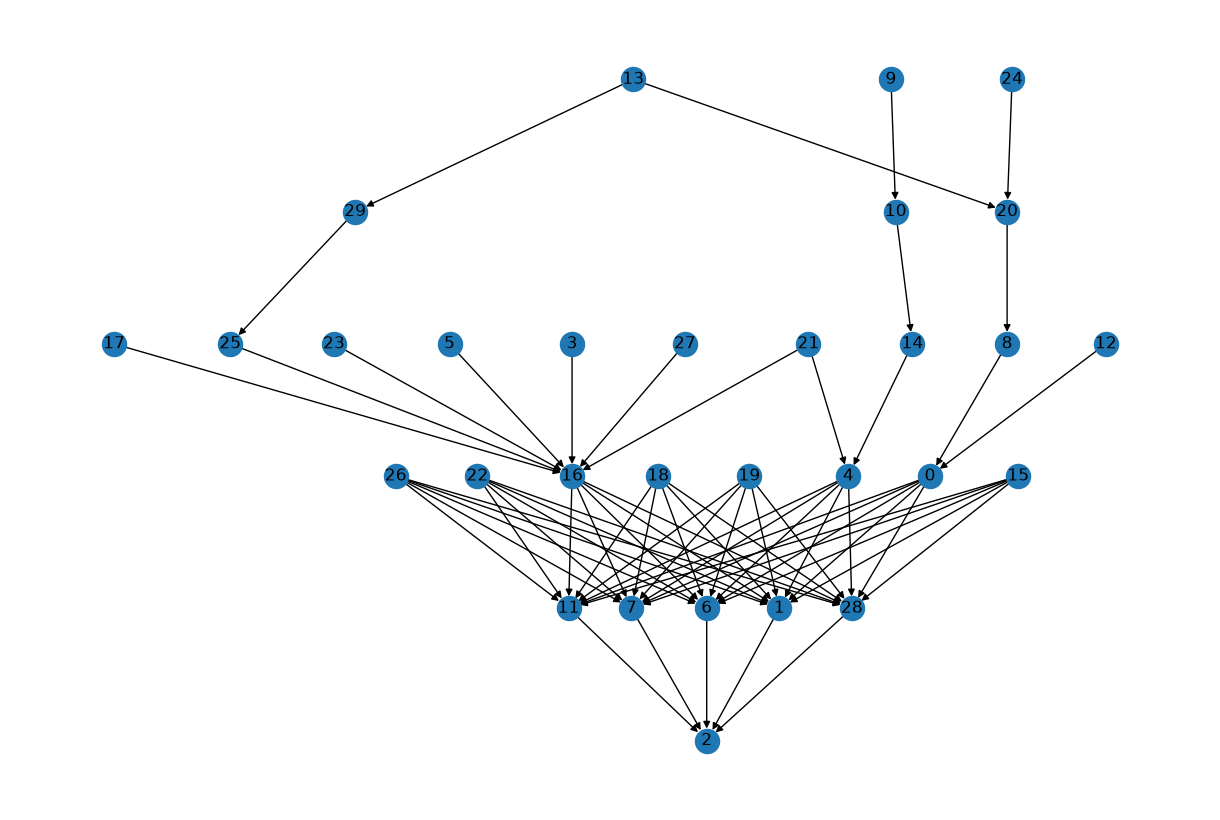

In [13]:
level_partitioned_digraph = get_final_digraph(networkx_graph)
labels = {
    node: i 
    for i,node in enumerate(sorted(level_partitioned_digraph.nodes()))
}
pos = nx.nx_agraph.graphviz_layout(level_partitioned_digraph, prog="dot")
plt.figure(figsize=(12, 8))
nx.draw(
    level_partitioned_digraph,
    pos=pos,
    labels=labels,
    with_labels=True
)

In [14]:
labels

{'Administrative Burden': 0,
 'Clinician Burnout': 1,
 'Community-Care / Private-Sector Outsourcing': 2,
 'Counselor and MFT Training Pipelines': 3,
 'Credentialing and Onboarding Delays': 4,
 'Education Debt-Reduction / Loan-Repayment Incentives': 5,
 'Employee Retention and Turnover': 6,
 'Excessive Caseloads': 7,
 'Excessive Documentation Requirements': 8,
 'Funding and Position-Authorization Constraints': 9,
 'HR Capacity and Recruitment Support': 10,
 'High Clinical Workload': 11,
 'Insufficient Administrative Support': 12,
 'Leadership Trust and Organizational Climate': 13,
 'Lengthy Federal Hiring Process': 14,
 'Limited Career Advancement Opportunities': 15,
 'Limited Qualified Applicant Pool': 16,
 'National Mental-Health Workforce Shortage': 17,
 'Noncompetitive Compensation': 18,
 'Private-Sector Employer Competition': 19,
 'Productivity and Performance Pressures': 20,
 'Psychology Internship and Fellowship Pipelines': 21,
 'Recruitment and Relocation Incentives': 22,
 'Reti